# 🌍 Statistics 101 Project — Air Quality Index (AQI) Analysis

**Dataset:** AQI and Lat Long of Countries.csv (Kaggle)

**Goal:** Apply the full Statistics 101 syllabus (Descriptive Statistics, Dispersion,
Skewness & Kurtosis, Correlation, Regression, Probability, Probability Distributions,
Sampling, Central Limit Theorem and Hypothesis Testing) on one real-world dataset,
module by module.

The dataset contains the Air Quality Index (AQI) of cities across the world, along with
the individual pollutant sub-indices (CO, Ozone, NO2, PM2.5) and their categories.

**Note:** Upload `AQI and Lat Long of Countries.csv` to your Colab environment
(left sidebar → Files → Upload) before running the cells below.


## 🔧 Step 0: Import Libraries

We import all the libraries needed for this project:
- `pandas`, `numpy` → data handling & numerical calculations
- `matplotlib`, `seaborn` → data visualization
- `scipy.stats` → skewness, kurtosis, correlation, probability distributions, hypothesis testing
- `sklearn.linear_model` → simple linear regression


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Make plots look a little nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


---
# 📘 Module 1: Data Understanding & Organization

In this module we:
1. Load the dataset
2. Understand its structure (rows, columns, data types)
3. Identify Qualitative vs Quantitative columns
4. Discuss Population vs Sample
5. Build a Frequency Table
6. Build a Grouped Frequency Distribution

"C:\Users\TANMAY GUPTA\Downloads\AQI and Lat Long of Countries.csv"


In [8]:
# 1. Load the dataset (from Colab session storage)
df = pd.read_csv("AQI and Lat Long of Countries.csv")

# Basic structure
print("Shape of dataset (rows, columns):", df.shape)
print()
print("Column names:")
print(df.columns.tolist())

Shape of dataset (rows, columns): (16695, 14)

Column names:
['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category', 'lat', 'lng']


In [9]:
# First 5 rows
df.head()


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,44.7444,44.2031
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-5.2900,-44.4900
2,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-11.2958,-41.9869
3,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,37.1667,15.1833
4,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,53.0167,20.8833


In [10]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             16393 non-null  object 
 1   City                16695 non-null  object 
 2   AQI Value           16695 non-null  int64  
 3   AQI Category        16695 non-null  object 
 4   CO AQI Value        16695 non-null  int64  
 5   CO AQI Category     16695 non-null  object 
 6   Ozone AQI Value     16695 non-null  int64  
 7   Ozone AQI Category  16695 non-null  object 
 8   NO2 AQI Value       16695 non-null  int64  
 9   NO2 AQI Category    16695 non-null  object 
 10  PM2.5 AQI Value     16695 non-null  int64  
 11  PM2.5 AQI Category  16695 non-null  object 
 12  lat                 16695 non-null  float64
 13  lng                 16695 non-null  float64
dtypes: float64(2), int64(5), object(7)
memory usage: 1.8+ MB


In [11]:
# Missing values in each column
df.isnull().sum()


,0
Country,302
City,0
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


### 🔹 Qualitative vs Quantitative Data

- **Qualitative (Categorical)** columns: `Country`, `City`, `AQI Category`,
  `CO AQI Category`, `Ozone AQI Category`, `NO2 AQI Category`, `PM2.5 AQI Category`
- **Quantitative (Numerical)** columns: `AQI Value`, `CO AQI Value`, `Ozone AQI Value`,
  `NO2 AQI Value`, `PM2.5 AQI Value`, `lat`, `lng`

### 🔹 Population vs Sample
The dataset contains **16,695 monitoring locations** across the world.
This is a **sample** — it does not cover every single city/location on Earth,
it is a collected sample used to represent the global AQI **population**.


In [12]:
# Total observations, minimum and maximum of AQI Value
print("Total observations:", df["AQI Value"].count())
print("Minimum AQI Value:", df["AQI Value"].min())
print("Maximum AQI Value:", df["AQI Value"].max())


Total observations: 16695
Minimum AQI Value: 7
Maximum AQI Value: 500


### 🔹 Frequency Table (AQI Category)
A frequency table counts how many rows fall into each category.


In [13]:
freq_table = df["AQI Category"].value_counts()
print(freq_table)


AQI Category
Good                              7708
Moderate                          7054
Unhealthy                          871
Unhealthy for Sensitive Groups     869
Very Unhealthy                     131
Hazardous                           62
Name: count, dtype: int64


### 🔹 Grouped Frequency Distribution (AQI Value)
We divide the numeric `AQI Value` column into class intervals and count how many
observations fall in each interval.


In [14]:
# Class intervals for AQI Value
bins = [0, 50, 100, 150, 200, 300, df["AQI Value"].max()]
labels = ["0-50 (Good)", "51-100 (Moderate)", "101-150 (Unhealthy-Sensitive)",
          "151-200 (Unhealthy)", "201-300 (Very Unhealthy)", "300+ (Hazardous)"]

df["AQI_Group"] = pd.cut(df["AQI Value"], bins=bins, labels=labels, include_lowest=True)

grouped_freq = df["AQI_Group"].value_counts().sort_index()
print(grouped_freq)


AQI_Group
0-50 (Good)                      7708
51-100 (Moderate)                7081
101-150 (Unhealthy-Sensitive)     899
151-200 (Unhealthy)               814
201-300 (Very Unhealthy)          131
300+ (Hazardous)                   62
Name: count, dtype: int64


---
# 📘 Module 2: Data Visualization

We visualize the AQI data using different types of graphs:
Histogram, Boxplot, Bar Chart, Pie Chart, Scatter Plot and Line Graph.
Every graph has a Title and X & Y labels as required.


### 🔹 Histogram of AQI Value

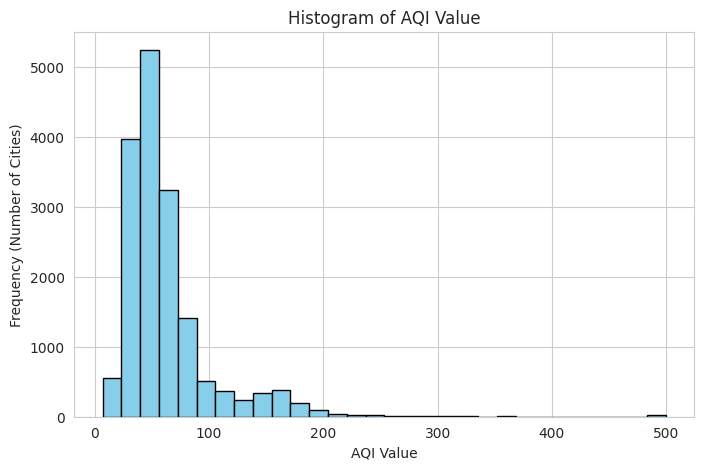

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["AQI Value"], bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of AQI Value")
plt.xlabel("AQI Value")
plt.ylabel("Frequency (Number of Cities)")
plt.show()


**Observation:** The histogram is not symmetric — it has a long tail on the right
side, which means the data is **positively (right) skewed**. Most cities have a
low-to-moderate AQI, while a few cities have very high AQI values.

### 🔹 Boxplot of AQI Value

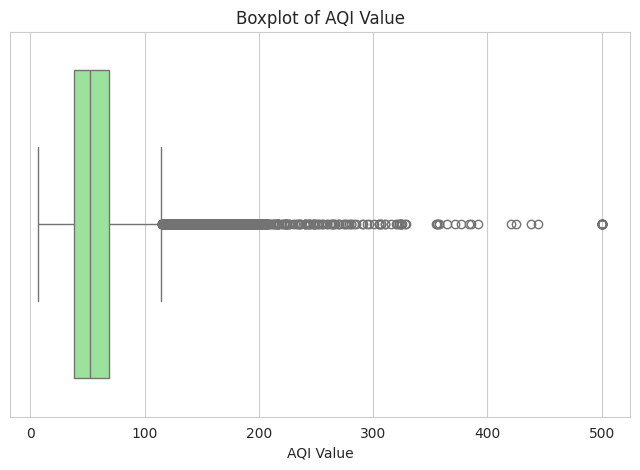

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["AQI Value"], color="lightgreen")
plt.title("Boxplot of AQI Value")
plt.xlabel("AQI Value")
plt.show()


### 🔹 Bar Chart — Count of Cities per AQI Category

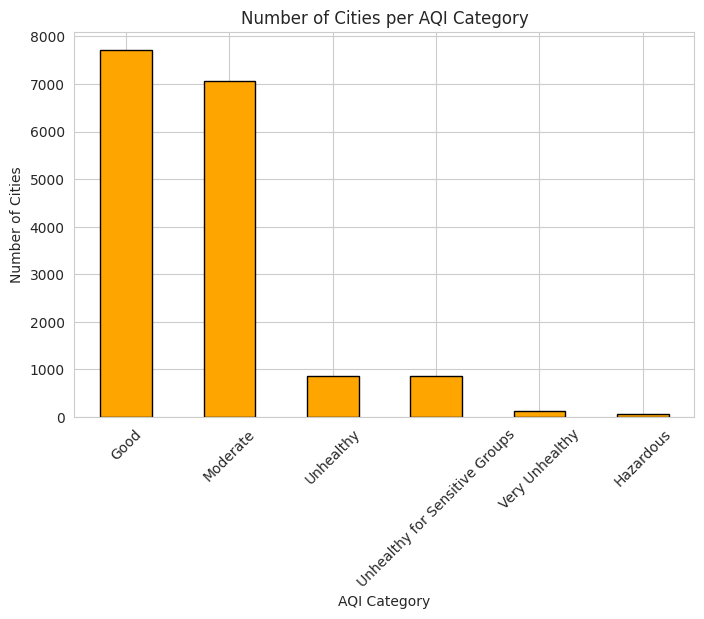

In [17]:
plt.figure(figsize=(8,5))
df["AQI Category"].value_counts().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Number of Cities per AQI Category")
plt.xlabel("AQI Category")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45)
plt.show()


### 🔹 Pie Chart — Share of Each AQI Category

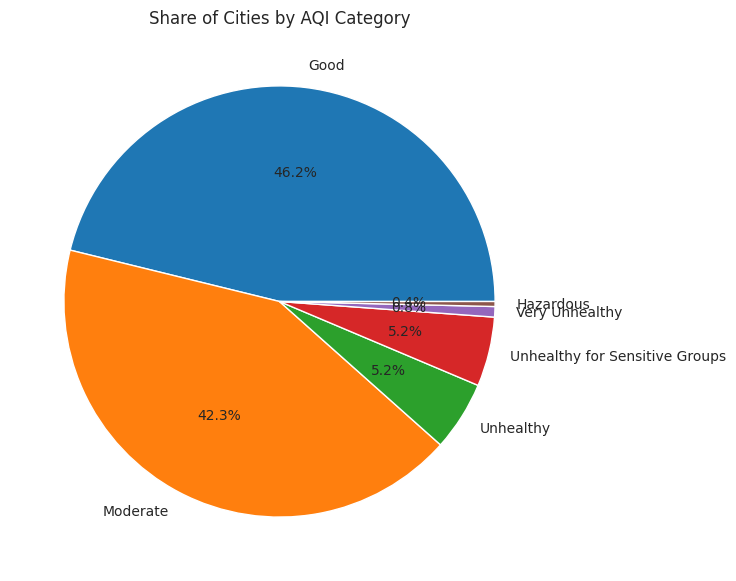

In [18]:
plt.figure(figsize=(7,7))
df["AQI Category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Share of Cities by AQI Category")
plt.ylabel("")
plt.show()


### 🔹 Scatter Plot — AQI Value vs PM2.5 AQI Value

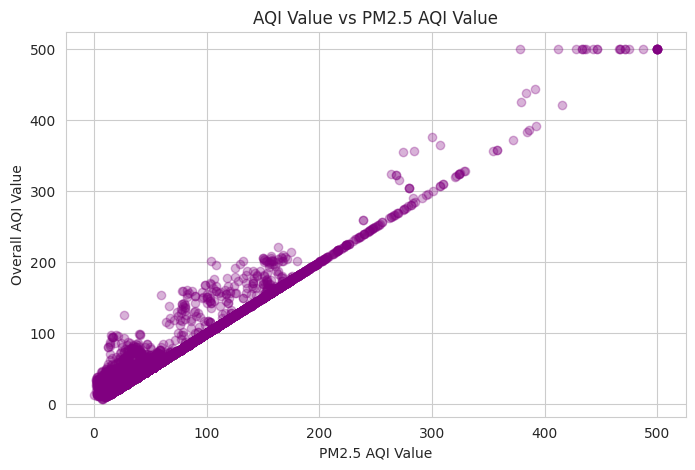

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df["PM2.5 AQI Value"], df["AQI Value"], alpha=0.3, color="purple")
plt.title("AQI Value vs PM2.5 AQI Value")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("Overall AQI Value")
plt.show()


### 🔹 Line Graph — Average AQI Value of Top 10 Countries
(A line graph works best on ordered/continuous data. Here we sort the top 10 countries
by their average AQI Value to visualize the trend.)

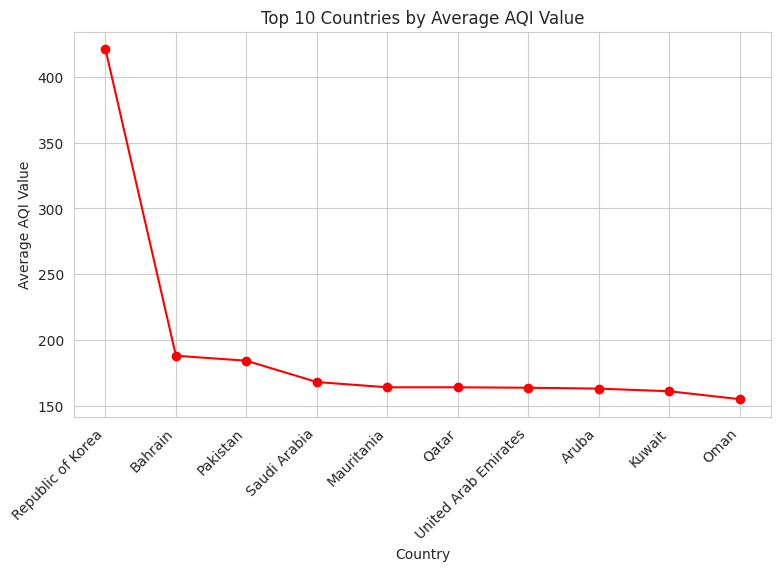

In [20]:
top10 = df.groupby("Country")["AQI Value"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
plt.plot(top10.index, top10.values, marker="o", color="red")
plt.title("Top 10 Countries by Average AQI Value")
plt.xlabel("Country")
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45, ha="right")
plt.show()


---
# 📘 Module 3: Measures of Central Tendency

We calculate Mean, Median, Mode, and Weighted Mean for the `AQI Value` column,
and compare Mean vs Median to understand the shape of the distribution.


In [21]:
mean_aqi = df["AQI Value"].mean()
median_aqi = df["AQI Value"].median()
mode_aqi = df["AQI Value"].mode()[0]

print("Mean AQI Value   :", round(mean_aqi, 2))
print("Median AQI Value :", median_aqi)
print("Mode AQI Value   :", mode_aqi)


Mean AQI Value   : 63.0
Median AQI Value : 52.0
Mode AQI Value   : 50


**Comparison:** Since Mean > Median, the data is **positively (right) skewed** —
this matches what we saw in the histogram in Module 2 (a few very high AQI cities
pull the mean upward).

### 🔹 Weighted Mean Example
We calculate the weighted mean AQI value of countries, weighted by number of cities recorded for each country (larger countries with more monitoring stations get more weight).

In [22]:
country_stats = df.groupby("Country")["AQI Value"].agg(["mean", "count"]).head(10)
print(country_stats)

# Weighted mean = sum(mean_i * count_i) / sum(count_i)   (using the first 10 countries as example)
weighted_mean = (country_stats["mean"] * country_stats["count"]).sum() / country_stats["count"].sum()
simple_mean = country_stats["mean"].mean()

print("\nSimple Mean of country averages  :", round(simple_mean, 2))
print("Weighted Mean (weighted by count) :", round(weighted_mean, 2))


                   mean  count
Country                       
Afghanistan   86.333333      3
Albania       77.111111      9
Algeria      106.250000      4
Andorra       32.000000      1
Angola        85.000000     21
Argentina     29.444444     72
Armenia       51.800000     20
Aruba        163.000000      2
Australia     34.000000     88
Austria       52.708333     48

Simple Mean of country averages  : 71.76
Weighted Mean (weighted by count) : 45.52


---
# 📘 Module 4: Measures of Dispersion

We calculate Range, Variance, Standard Deviation, IQR and Coefficient of Variation (CV)
for the overall `AQI Value`, and then compare the consistency of AQI between two
countries using CV.


In [23]:
aqi = df["AQI Value"]

data_range = aqi.max() - aqi.min()
variance = aqi.var()
std_dev = aqi.std()
Q1 = aqi.quantile(0.25)
Q3 = aqi.quantile(0.75)
IQR = Q3 - Q1
CV = (std_dev / aqi.mean()) * 100

print("Range               :", data_range)
print("Variance            :", round(variance, 2))
print("Standard Deviation  :", round(std_dev, 2))
print("Q1                  :", Q1)
print("Q3                  :", Q3)
print("IQR                 :", IQR)
print("Coefficient of Variation (%):", round(CV, 2))


Range               : 493
Variance            : 1856.92
Standard Deviation  : 43.09
Q1                  : 38.5
Q3                  : 69.0
IQR                 : 30.5
Coefficient of Variation (%): 68.4


### 🔹 Detecting Outliers using the IQR Method

In [24]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["AQI Value"] < lower_bound) | (df["AQI Value"] > upper_bound)]
print("Lower bound:", lower_bound, " Upper bound:", upper_bound)
print("Number of outlier cities:", outliers.shape[0])


Lower bound: -7.25  Upper bound: 114.75
Number of outlier cities: 1573


### 🔹 Comparing Consistency of Two Countries (using CV)

In [25]:
country_A = "India"
country_B = "United States of America"

for c in [country_A, country_B]:
    subset = df[df["Country"] == c]["AQI Value"]
    mean_c = subset.mean()
    std_c = subset.std()
    cv_c = (std_c / mean_c) * 100
    print(f"{c}: Mean={mean_c:.2f}, Std Dev={std_c:.2f}, CV={cv_c:.2f}%")

print("\nLower CV = more consistent / stable AQI across cities.")


India: Mean=142.73, Std Dev=85.79, CV=60.10%
United States of America: Mean=59.83, Std Dev=24.07, CV=40.23%

Lower CV = more consistent / stable AQI across cities.


---
# 📘 Module 5: Skewness Analysis

Skewness measures the asymmetry of the distribution.
We calculate **Karl Pearson's Coefficient of Skewness** for `AQI Value`.


In [26]:
mean_aqi = df["AQI Value"].mean()
median_aqi = df["AQI Value"].median()
mode_aqi = df["AQI Value"].mode()[0]
std_aqi = df["AQI Value"].std()

# Karl Pearson's Coefficient of Skewness (using mode)
skew_pearson_mode = (mean_aqi - mode_aqi) / std_aqi

# Karl Pearson's Coefficient of Skewness (using median) -- more reliable when mode is not unique
skew_pearson_median = 3 * (mean_aqi - median_aqi) / std_aqi

# Skewness using scipy (moment based)
skew_scipy = stats.skew(df["AQI Value"])

print("Skewness (Mode formula)   :", round(skew_pearson_mode, 3))
print("Skewness (Median formula) :", round(skew_pearson_median, 3))
print("Skewness (scipy.stats)    :", round(skew_scipy, 3))

if skew_scipy > 0:
    print("\nType of Skewness: Positively Skewed (Right Skewed)")
elif skew_scipy < 0:
    print("\nType of Skewness: Negatively Skewed (Left Skewed)")
else:
    print("\nType of Skewness: Symmetrical")


Skewness (Mode formula)   : 0.302
Skewness (Median formula) : 0.766
Skewness (scipy.stats)    : 3.584

Type of Skewness: Positively Skewed (Right Skewed)


### 🔹 Histogram with Smooth Density Curve

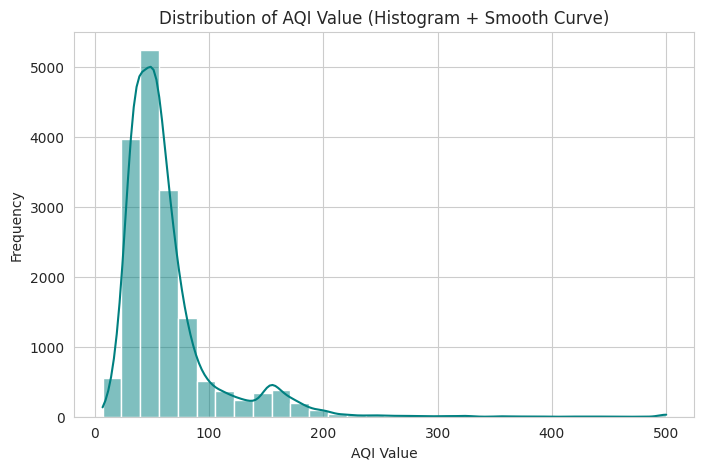

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["AQI Value"], bins=30, kde=True, color="teal")
plt.title("Distribution of AQI Value (Histogram + Smooth Curve)")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()


---
# 📘 Module 6: Kurtosis Analysis

Kurtosis measures the "peakedness" of the distribution compared to a Normal distribution.


In [28]:
# Pearson's Kurtosis (beta_2) = 3 + excess kurtosis   (scipy returns EXCESS kurtosis by default)
excess_kurtosis = stats.kurtosis(df["AQI Value"])   # fisher=True by default -> excess kurtosis
pearson_kurtosis = excess_kurtosis + 3               # beta_2

print("Excess Kurtosis   :", round(excess_kurtosis, 3))
print("Pearson's Kurtosis (beta_2) :", round(pearson_kurtosis, 3))

if pearson_kurtosis > 3:
    print("\nType: Leptokurtic (sharp peak, heavy tails)")
elif pearson_kurtosis < 3:
    print("\nType: Platykurtic (flat peak, light tails)")
else:
    print("\nType: Mesokurtic (normal peak)")


Excess Kurtosis   : 22.827
Pearson's Kurtosis (beta_2) : 25.827

Type: Leptokurtic (sharp peak, heavy tails)


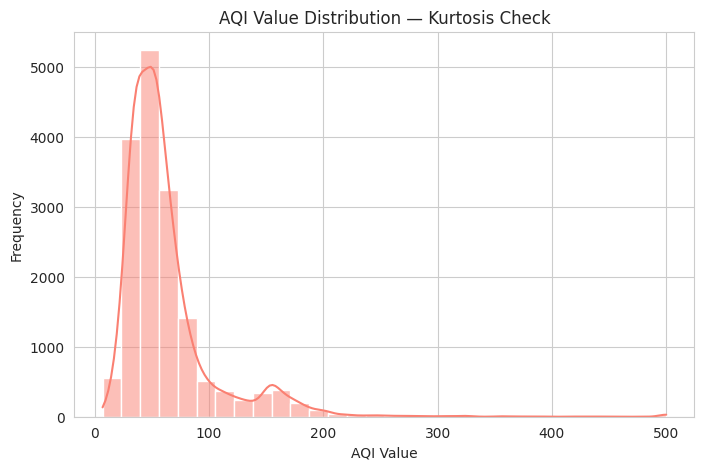

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["AQI Value"], bins=30, kde=True, color="salmon")
plt.title("AQI Value Distribution — Kurtosis Check")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()


---
# 📘 Module 7: Correlation Analysis (Pearson & Spearman)

We check how strongly `AQI Value` is related to `PM2.5 AQI Value` (the pollutant that
usually drives overall AQI the most).


### 🔹 Scatter Plot

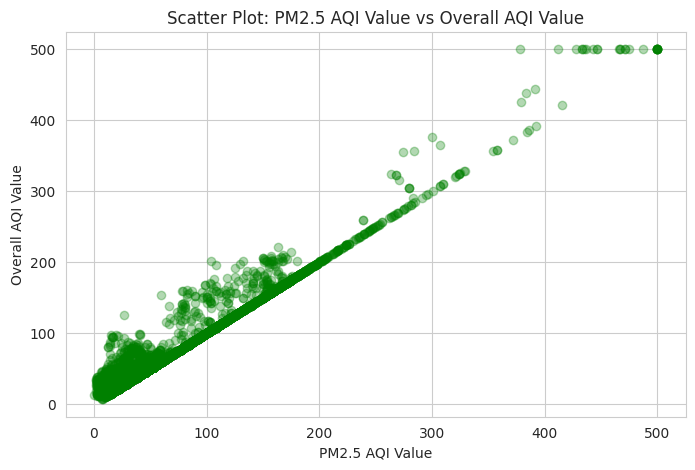

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["PM2.5 AQI Value"], df["AQI Value"], alpha=0.3, color="green")
plt.title("Scatter Plot: PM2.5 AQI Value vs Overall AQI Value")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("Overall AQI Value")
plt.show()


### 🔹 Pearson's Correlation Coefficient

In [31]:
pearson_corr, p_value = stats.pearsonr(df["PM2.5 AQI Value"], df["AQI Value"])
print("Pearson's Correlation Coefficient (r):", round(pearson_corr, 3))
print("p-value:", p_value)

if p_value < 0.05:
    print("The correlation is statistically significant (p < 0.05).")
else:
    print("The correlation is NOT statistically significant (p >= 0.05).")


Pearson's Correlation Coefficient (r): 0.98
p-value: 0.0
The correlation is statistically significant (p < 0.05).


**Interpretation:** A value of `r` close to `+1` means a strong positive
correlation — as PM2.5 AQI Value increases, the overall AQI Value also increases.

### 🔹 Correlation of All Pollutants with Overall AQI (Correlation Matrix)

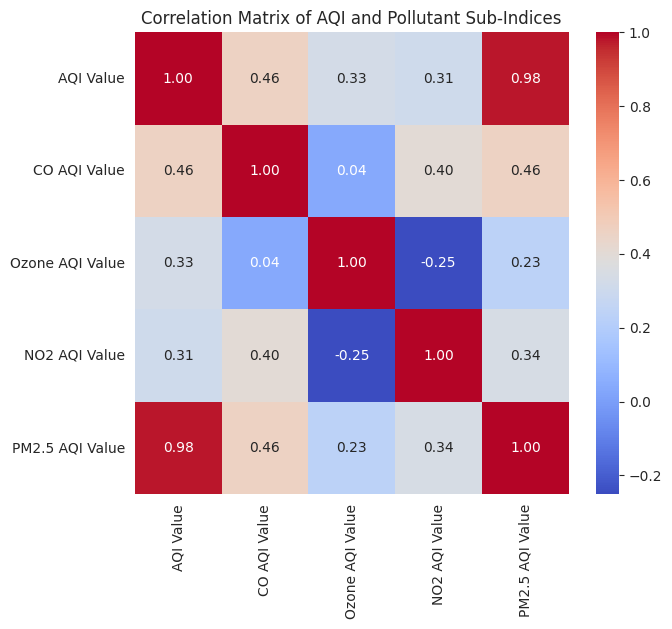

In [32]:
num_cols = ["AQI Value", "CO AQI Value", "Ozone AQI Value", "NO2 AQI Value", "PM2.5 AQI Value"]
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of AQI and Pollutant Sub-Indices")
plt.show()


### 🔹 Spearman's Rank Correlation

In [33]:
spearman_corr, sp_p_value = stats.spearmanr(df["PM2.5 AQI Value"], df["AQI Value"])
print("Spearman's Rank Correlation:", round(spearman_corr, 3))
print("p-value:", sp_p_value)

print("\nComparison:")
print("Pearson r  :", round(pearson_corr, 3), " (measures linear relationship using actual values)")
print("Spearman rs:", round(spearman_corr, 3), " (measures monotonic relationship using ranks)")


Spearman's Rank Correlation: 0.959
p-value: 0.0

Comparison:
Pearson r  : 0.98  (measures linear relationship using actual values)
Spearman rs: 0.959  (measures monotonic relationship using ranks)


---
# 📘 Module 8: Simple Linear Regression

We predict the overall `AQI Value` using `PM2.5 AQI Value` as the independent variable.


In [34]:
X = df[["PM2.5 AQI Value"]]   # Independent variable (must be 2D)
y = df["AQI Value"]            # Dependent variable

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Regression Equation: AQI Value =", round(intercept, 2), "+", round(slope, 2), "* PM2.5 AQI Value")
print("Slope (b1)    :", round(slope, 3))
print("Intercept (b0):", round(intercept, 3))


Regression Equation: AQI Value = 4.51 + 0.98 * PM2.5 AQI Value
Slope (b1)    : 0.978
Intercept (b0): 4.51


### 🔹 Interpretation of Slope and Intercept
- **Slope:** For every 1 unit increase in PM2.5 AQI Value, the overall AQI Value
  increases by approximately the slope value shown above.
- **Intercept:** The predicted overall AQI Value when PM2.5 AQI Value = 0.


### 🔹 Regression Line with Scatter Plot

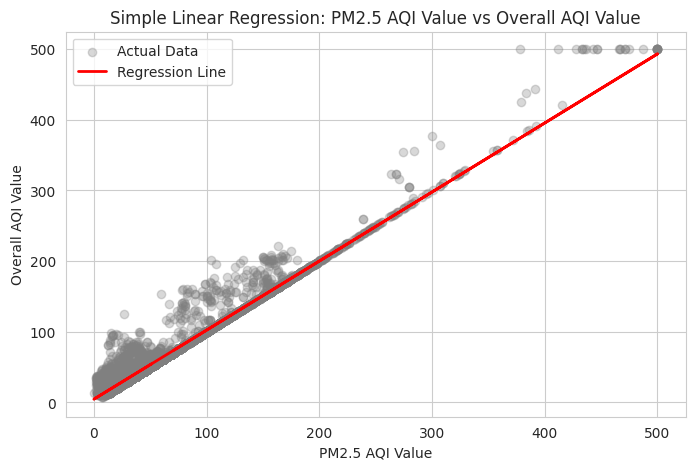

In [35]:
y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(df["PM2.5 AQI Value"], df["AQI Value"], alpha=0.3, color="gray", label="Actual Data")
plt.plot(df["PM2.5 AQI Value"], y_pred, color="red", linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression: PM2.5 AQI Value vs Overall AQI Value")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("Overall AQI Value")
plt.legend()
plt.show()


### 🔹 Prediction Example

In [36]:
pm25_input = 120
predicted_aqi = model.predict([[pm25_input]])[0]
print(f"Predicted overall AQI Value when PM2.5 AQI Value = {pm25_input}: {predicted_aqi:.2f}")


Predicted overall AQI Value when PM2.5 AQI Value = 120: 121.84


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
# 📘 Module 9: Probability Basics

We apply Classical, Empirical, and Subjective Probability concepts using the AQI dataset,
and verify basic rules of probability (Complement Rule, Addition Rule).


### 🔹 Empirical Probability
What is the probability that a randomly picked city has AQI Category = 'Good'?

In [37]:
total_cities = df.shape[0]
good_cities = df[df["AQI Category"] == "Good"].shape[0]

p_good = good_cities / total_cities
print("Empirical Probability of 'Good' AQI Category:", round(p_good, 4))


Empirical Probability of 'Good' AQI Category: 0.4617


### 🔹 Classical Probability Example
If we assume every AQI Category is equally likely (classical/theoretical assumption), and there are 6 categories, the classical probability of picking any one category is:

In [38]:
categories = df["AQI Category"].unique()
n_categories = len(categories)
classical_p = 1 / n_categories
print("Categories:", categories)
print("Classical probability of any one category (equally likely assumption):", round(classical_p, 4))


Categories: ['Moderate' 'Good' 'Unhealthy' 'Very Unhealthy'
 'Unhealthy for Sensitive Groups' 'Hazardous']
Classical probability of any one category (equally likely assumption): 0.1667


### 🔹 Rule 1: Probability Range Check

In [39]:
p = p_good
print("Is probability valid? (0 <= p <= 1):", 0 <= p <= 1)


Is probability valid? (0 <= p <= 1): True


### 🔹 Rule 2: Complement Rule
P(Not Good) = 1 - P(Good)

In [40]:
p_not_good = 1 - p_good
print("P(Good)     :", round(p_good, 4))
print("P(Not Good) :", round(p_not_good, 4))


P(Good)     : 0.4617
P(Not Good) : 0.5383


### 🔹 Rule 3: Addition Rule (Non-Mutually Exclusive)
P(Good OR Moderate) = P(Good) + P(Moderate) - P(Good AND Moderate)
Since a city cannot be both 'Good' and 'Moderate' at once, these are mutually exclusive, so P(Good ∩ Moderate) = 0.

In [41]:
p_moderate = df[df["AQI Category"] == "Moderate"].shape[0] / total_cities

p_good_or_moderate = p_good + p_moderate  # mutually exclusive -> no overlap
print("P(Good)              :", round(p_good, 4))
print("P(Moderate)           :", round(p_moderate, 4))
print("P(Good OR Moderate)   :", round(p_good_or_moderate, 4))


P(Good)              : 0.4617
P(Moderate)           : 0.4225
P(Good OR Moderate)   : 0.8842


### 🔹 Subjective Probability
Subjective probability is based on personal judgment rather than data — for example,
*"I believe there is a 70% chance tomorrow's city AQI reading will be 'Good'."*
This cannot be calculated from the dataset; it is simply a belief/opinion, unlike the
Empirical and Classical probabilities calculated above.

---
# 📘 Module 10: Probability Distributions (Binomial, Poisson, Normal)

We use the empirical probability of 'Good' AQI Category (calculated in Module 9)
to simulate a Binomial distribution, model rare-event counts using Poisson,
and check whether `AQI Value` follows a Normal distribution.


### 🔹 Binomial Distribution
If we randomly pick 10 cities, how many of them are expected to be 'Good' AQI Category?

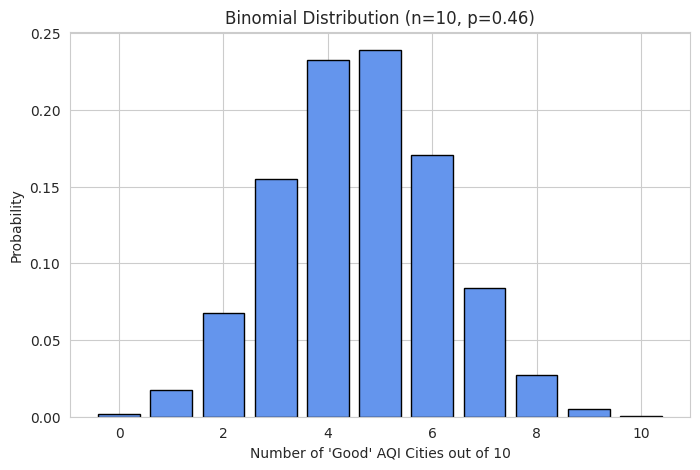

Theoretical Mean (n*p)      : 4.617
Theoretical Variance        : 2.485


In [42]:
n_trials = 10
p_success = p_good     # probability of 'Good' from Module 9

x = np.arange(0, n_trials + 1)
binomial_probs = stats.binom.pmf(x, n_trials, p_success)

plt.figure(figsize=(8,5))
plt.bar(x, binomial_probs, color="cornflowerblue", edgecolor="black")
plt.title(f"Binomial Distribution (n={n_trials}, p={p_success:.2f})")
plt.xlabel("Number of 'Good' AQI Cities out of 10")
plt.ylabel("Probability")
plt.show()

mean_binom = n_trials * p_success
var_binom = n_trials * p_success * (1 - p_success)
print("Theoretical Mean (n*p)      :", round(mean_binom, 3))
print("Theoretical Variance        :", round(var_binom, 3))


### 🔹 Poisson Distribution
Suppose on average, 3 cities out of every 100 have a 'Hazardous' AQI reading. We model the number of 'Hazardous' cities in a random group of 100 using a Poisson distribution.

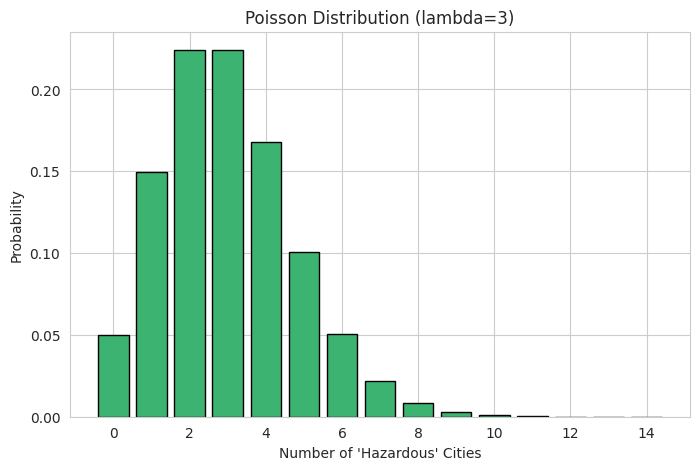

P(X = 0 Hazardous cities) : 0.0498
P(X >= 1 Hazardous city)  : 0.9502


In [43]:
lam = 3   # average rate (lambda)
x_poisson = np.arange(0, 15)
poisson_probs = stats.poisson.pmf(x_poisson, lam)

plt.figure(figsize=(8,5))
plt.bar(x_poisson, poisson_probs, color="mediumseagreen", edgecolor="black")
plt.title(f"Poisson Distribution (lambda={lam})")
plt.xlabel("Number of 'Hazardous' Cities")
plt.ylabel("Probability")
plt.show()

p_zero = stats.poisson.pmf(0, lam)
p_at_least_one = 1 - p_zero
print("P(X = 0 Hazardous cities) :", round(p_zero, 4))
print("P(X >= 1 Hazardous city)  :", round(p_at_least_one, 4))


### 🔹 Normal Distribution Check on AQI Value

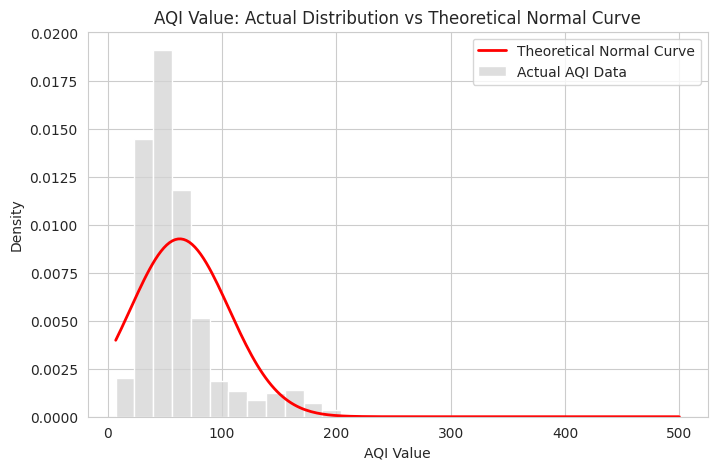

In [44]:
mean_aqi = df["AQI Value"].mean()
std_aqi = df["AQI Value"].std()

plt.figure(figsize=(8,5))
sns.histplot(df["AQI Value"], bins=30, stat="density", color="lightgray", label="Actual AQI Data")

x_range = np.linspace(df["AQI Value"].min(), df["AQI Value"].max(), 200)
normal_curve = stats.norm.pdf(x_range, mean_aqi, std_aqi)
plt.plot(x_range, normal_curve, color="red", linewidth=2, label="Theoretical Normal Curve")

plt.title("AQI Value: Actual Distribution vs Theoretical Normal Curve")
plt.xlabel("AQI Value")
plt.ylabel("Density")
plt.legend()
plt.show()


In [45]:
# Percentage of cities with AQI Value greater than 150 (using Z-score / Normal assumption)
threshold = 150
z_score = (threshold - mean_aqi) / std_aqi
prob_greater = 1 - stats.norm.cdf(z_score)

print("Z-score for AQI Value =", threshold, ":", round(z_score, 3))
print("Theoretical % of cities with AQI Value > 150 (Normal assumption):", round(prob_greater*100, 2), "%")

actual_percent = (df["AQI Value"] > threshold).mean() * 100
print("Actual % of cities with AQI Value > 150 (from real data)       :", round(actual_percent, 2), "%")


Z-score for AQI Value = 150 : 2.019
Theoretical % of cities with AQI Value > 150 (Normal assumption): 2.17 %
Actual % of cities with AQI Value > 150 (from real data)       : 6.03 %


**Note:** Since AQI Value is right-skewed (Module 5), the Normal distribution is only
an approximation — the actual percentage and the theoretical Normal percentage will differ.

---
# 📘 Module 11: Sampling and Central Limit Theorem (CLT)

We demonstrate different sampling techniques, then use the Central Limit Theorem to show
that sample means become approximately Normal even though `AQI Value` itself is skewed.


### 🔹 Simple Random Sampling

In [46]:
simple_random_sample = df["AQI Value"].sample(n=100, random_state=1)
print("Simple Random Sample Mean (n=100):", round(simple_random_sample.mean(), 2))


Simple Random Sample Mean (n=100): 64.87


### 🔹 Stratified Sampling (by AQI Category)

In [47]:
stratified_sample = df.groupby("AQI Category", group_keys=False).sample(frac=0.05, random_state=1)

print("Stratified sample size:", stratified_sample.shape[0])
print(stratified_sample["AQI Category"].value_counts())


Stratified sample size: 835
AQI Category
Good                              385
Moderate                          353
Unhealthy                          44
Unhealthy for Sensitive Groups     43
Very Unhealthy                      7
Hazardous                           3
Name: count, dtype: int64


### 🔹 Systematic Sampling (every 10th row)

In [48]:
systematic_sample = df.iloc[::10]
print("Systematic sample size:", systematic_sample.shape[0])


Systematic sample size: 1670


### 🔹 Central Limit Theorem Demonstration
We repeatedly draw random samples of different sizes from the population, calculate the mean of each sample, and plot the distribution of these sample means.

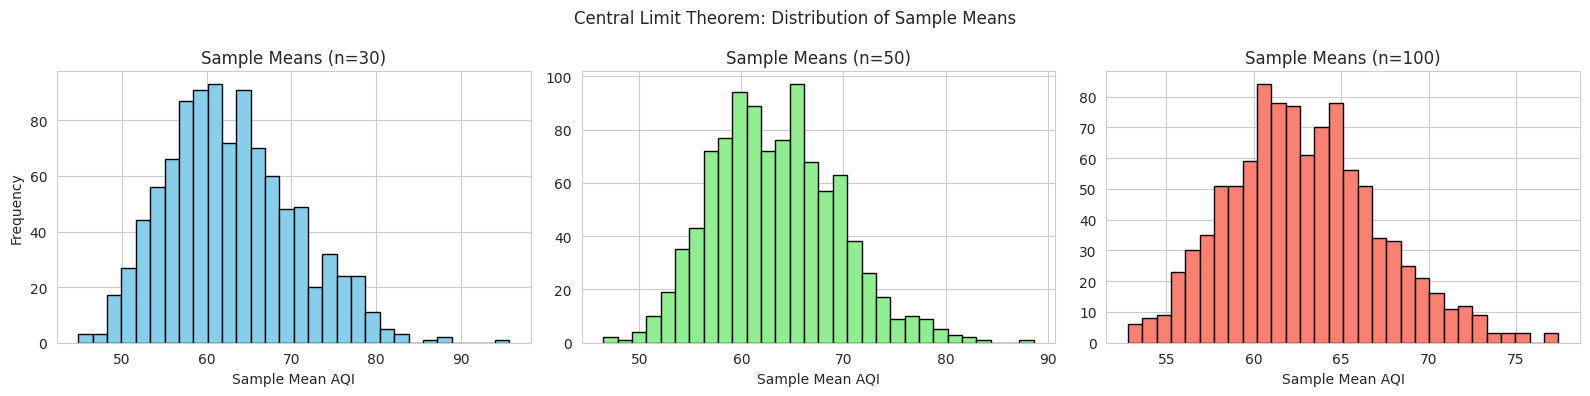

In [49]:
population = df["AQI Value"].values

def sample_means(pop, sample_size, n_repeats=1000):
    means = []
    for _ in range(n_repeats):
        sample = np.random.choice(pop, size=sample_size, replace=True)
        means.append(sample.mean())
    return means

means_30  = sample_means(population, 30)
means_50  = sample_means(population, 50)
means_100 = sample_means(population, 100)

fig, axes = plt.subplots(1, 3, figsize=(16,4))

axes[0].hist(means_30, bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Sample Means (n=30)")
axes[0].set_xlabel("Sample Mean AQI")
axes[0].set_ylabel("Frequency")

axes[1].hist(means_50, bins=30, color="lightgreen", edgecolor="black")
axes[1].set_title("Sample Means (n=50)")
axes[1].set_xlabel("Sample Mean AQI")

axes[2].hist(means_100, bins=30, color="salmon", edgecolor="black")
axes[2].set_title("Sample Means (n=100)")
axes[2].set_xlabel("Sample Mean AQI")

plt.suptitle("Central Limit Theorem: Distribution of Sample Means")
plt.tight_layout()
plt.show()


**Observation:** Even though the original `AQI Value` distribution is right-skewed
(Module 5), the distribution of sample means becomes more bell-shaped (Normal) as the
sample size increases — this is the Central Limit Theorem in action.

### 🔹 Standard Error vs Sample Size

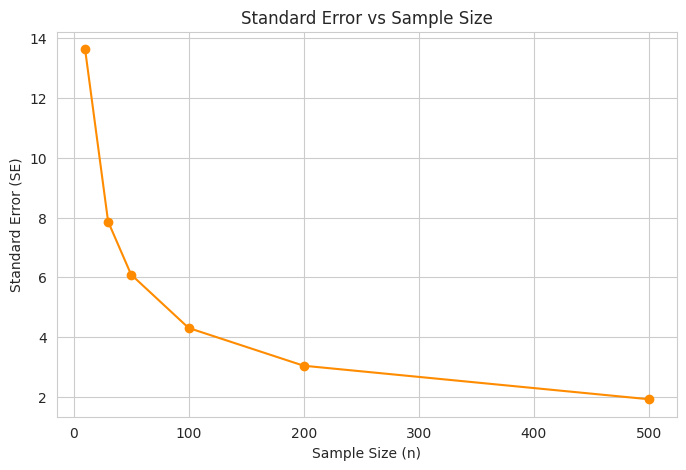

n =   10  ->  Standard Error = 13.627
n =   30  ->  Standard Error = 7.867
n =   50  ->  Standard Error = 6.094
n =  100  ->  Standard Error = 4.309
n =  200  ->  Standard Error = 3.047
n =  500  ->  Standard Error = 1.927


In [50]:
population_std = df["AQI Value"].std()
sample_sizes = [10, 30, 50, 100, 200, 500]
standard_errors = [population_std / np.sqrt(n) for n in sample_sizes]

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, standard_errors, marker="o", color="darkorange")
plt.title("Standard Error vs Sample Size")
plt.xlabel("Sample Size (n)")
plt.ylabel("Standard Error (SE)")
plt.show()

for n, se in zip(sample_sizes, standard_errors):
    print(f"n = {n:4d}  ->  Standard Error = {se:.3f}")


**Observation:** As sample size increases, the Standard Error decreases — larger
samples give more reliable (precise) estimates of the population mean.

---
# 📘 Module 12: Hypothesis Testing

We test whether the average AQI Value of two countries is significantly different,
using a **Two-Sample t-test**.


### 🔹 Setting up the Hypothesis

**Claim:** India and United States of America have different average AQI Values.

- **Null Hypothesis (H₀):** There is no difference in average AQI Value between India and the USA.
- **Alternative Hypothesis (H₁):** There is a significant difference in average AQI Value between India and the USA.


In [51]:
india_aqi = df[df["Country"] == "India"]["AQI Value"]
usa_aqi = df[df["Country"] == "United States of America"]["AQI Value"]

print("India   -> n:", len(india_aqi), " Mean:", round(india_aqi.mean(), 2))
print("USA     -> n:", len(usa_aqi), " Mean:", round(usa_aqi.mean(), 2))


India   -> n: 794  Mean: 142.73
USA     -> n: 3954  Mean: 59.83


In [52]:
t_stat, p_value = stats.ttest_ind(india_aqi, usa_aqi, equal_var=False)

print("t-statistic:", round(t_stat, 3))
print("p-value    :", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nDecision: Reject H0 -> There IS a statistically significant difference in AQI Value between India and USA.")
else:
    print("\nDecision: Fail to Reject H0 -> There is NOT enough evidence of a difference in AQI Value.")


t-statistic: 27.017
p-value    : 2.0227040508973654e-115

Decision: Reject H0 -> There IS a statistically significant difference in AQI Value between India and USA.


### 🔹 Visual Comparison

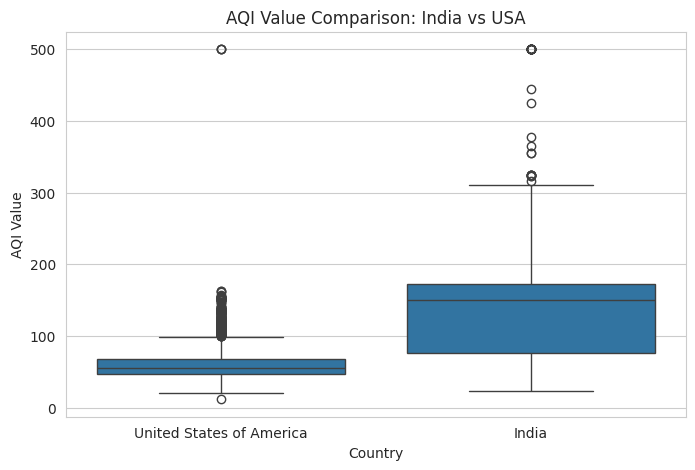

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Country", y="AQI Value", data=df[df["Country"].isin(["India", "United States of America"])])
plt.title("AQI Value Comparison: India vs USA")
plt.xlabel("Country")
plt.ylabel("AQI Value")
plt.show()


---
# ✅ Conclusion

In this project we applied the complete Statistics 101 syllabus on a real-world
Air Quality Index dataset:

1. Data Understanding & Organization
2. Data Visualization
3. Measures of Central Tendency
4. Measures of Dispersion
5. Skewness Analysis
6. Kurtosis Analysis
7. Correlation Analysis (Pearson & Spearman)
8. Regression Analysis
9. Probability Basics
10. Probability Distributions (Binomial, Poisson, Normal)
11. Sampling & Central Limit Theorem
12. Hypothesis Testing

**Key Findings:**
- AQI Value is **positively skewed** — a small number of cities have very high pollution.
- **PM2.5 AQI Value** is the strongest driver of the overall AQI Value (highest correlation).
- The Central Limit Theorem holds true: sample means become approximately Normal even
  though the original AQI data is skewed.
